# A default MicrobioLink run, for first-time users (notebook)

This notebook is the **gentlest** way into MicrobioLink. It runs the pipeline the
way a first-time user most often wants it: the **forward direction only** (a
microbial protein presenting a domain that grabs a motif on a host protein), at
the full depth of the pipeline, but without the two branches a newcomer rarely
needs on a first pass &mdash; the [Z-score filter](../concepts.md#1-z-score-filter)
and the [DDI side branch](../concepts.md#5-domain-domain-interactions-ddi).

When you want *everything* &mdash; both directions and every module &mdash; move on
to the [comprehensive notebook](t1_api_full.md). The same run from the terminal is
in the [default command-line tutorial](t4_cli_basic.md).

**The biology.** As in the other tutorials: *Bacteroides thetaiotaomicron*
outer-membrane-vesicle (OMV) proteins against human colonic enterocyte (BEST4)
proteins, in Crohn's disease. See [`data/README.md`](data/README.md).

**Before you start**

- Install the extras this notebook uses:
  `pip install "microbiolink[idr,tiedie,enrichment]"`
  (see [Get Started](../get-started.md#optional-extras)).
- The pipeline and the meaning of *forward* are defined in
  [Pipeline Concepts](../concepts.md).
- The local core (IDR &rarr; Monte Carlo) is deterministic (`iupred`, `seed=0`);
  the download, TieDie and enrichment stages fetch live data, so counts can drift
  slightly.

## Setup

The forward run needs a smaller slice of the API than the comprehensive one: no
Z-score filter, no DDI.

In [1]:
%matplotlib inline
import logging
from pathlib import Path

import pandas as pd

# The live-lookup libraries (mygene/biothings, gget) log a line per query. They
# re-assert their own log level when imported, so a plain setLevel does not stick;
# attach a filter that drops their records and stop them propagating to the root.
class _DropRecords(logging.Filter):
    def filter(self, record):
        return False

for _noisy in ("biothings.client", "gget", "gget.utils", "mygene"):
    _lg = logging.getLogger(_noisy)
    _lg.addFilter(_DropRecords())
    _lg.propagate = False
    _lg.setLevel(logging.ERROR)

from microbiolink.workflow.membrane_filter import filter_membrane_proteins
from microbiolink.workflow.fasta_download import download_fasta
from microbiolink.workflow.domain_download import download_domains
from microbiolink.workflow.dmi import predict_domain_motif_interactions
from microbiolink.workflow.idr_filter import filter_by_disorder
from microbiolink.workflow.monte_carlo import filter_by_monte_carlo
from microbiolink.workflow.tiedie import run_tiedie_pipeline
from microbiolink.workflow.enrichment import run_enrichment_analysis
from microbiolink.utils.fasta import read_fasta_sequences

DATA = Path("data")
WORK = Path("t2_work")
WORK.mkdir(exist_ok=True)

## The proteins

Two identifier lists: the human host proteins and the bacterial OMV proteins.

In [2]:
human_ids = pd.read_csv(DATA / "human_proteins.csv")["uniprot_id"].tolist()
bacterial_ids = pd.read_csv(DATA / "bacterial_proteins.csv")["uniprot_id"].tolist()
print(f"{len(human_ids)} human proteins, {len(bacterial_ids)} bacterial (OMV) proteins")

276 human proteins, 243 bacterial (OMV) proteins


## Membrane filter (host side)

We keep the human proteins that are surface-exposed or secreted &mdash; the ones
that can physically meet a microbial protein &mdash; using OmniPath's Intercell
classification. The bacterial OMV proteins are already a localized
(outer-membrane-vesicle) fraction, so we use them directly, without a filter (see
[`data/README.md`](data/README.md)).

In [3]:
HUMAN_LOCATIONS = [
    "plasma_membrane_transmembrane",
    "plasma_membrane_peripheral",
    "secreted",
    "cell_surface",
]
membrane_human = filter_membrane_proteins(human_ids, "uniprot", "human", HUMAN_LOCATIONS)
human_surface = membrane_human["uniprot_id"].tolist()
print(f"human: {len(human_ids)} -> {len(human_surface)} surface/secreted; bacterial: {len(bacterial_ids)} used directly")

human: 276 -> 270 surface/secreted; bacterial: 243 used directly


## Sequences and domains &mdash; the forward direction only

This is where *forward-only* saves work. In the forward direction the **human**
protein carries the motif and the **bacterial** protein carries the domain, so we
need only the **human FASTA** (to search motifs in) and the **bacterial domains**
(to match them against). No bacterial FASTA, no human domains.

In [4]:
fasta_paths = download_fasta(
    WORK,
    human_identifiers=human_surface,
    human_id_type="uniprot",
)
human_sequences = read_fasta_sequences(fasta_paths["human"])

domains = download_domains(
    microbial_identifiers=bacterial_ids,
    microbial_id_type="uniprot",
)
bacterial_domains = domains["microbial"]
print(f"{len(human_sequences)} human sequences, {len(bacterial_domains)} bacterial Pfam domains")

270 human sequences, 323 bacterial Pfam domains


## Domain&ndash;motif interactions (forward)

The core prediction, in `mode="forward"`: bacterial domain &rarr; human motif.

In [5]:
dmi = predict_domain_motif_interactions(
    "forward",
    human_sequences=human_sequences,
    bacterial_domains=bacterial_domains,
)
print(f"{len(dmi)} forward DMIs")
dmi.head()

19104 forward DMIs


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource
0,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_PC1ET2_1|CLV_PCSK_KEX2_1,285,288,ELM
1,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,73,78,ELM
2,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,90,95,ELM
3,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,167,172,ELM
4,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,185,190,ELM


## IDR filter

Keep only the DMIs whose motif sits in a disordered, binding-competent region
(`iupred`, cut-offs `0.5`). Only human sequences are needed &mdash; every row is a
forward interaction, so the motif is always on the human side.

In [6]:
idr = filter_by_disorder(
    dmi,
    human_sequences,
    None,
    method="iupred",
    disorder_cutoff=0.5,
    binding_cutoff=0.5,
)
print(f"{len(idr)} DMIs pass the IDR filter")
idr.head()

1463 DMIs pass the IDR filter


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource,disordered_score,binding_score,combined_score
0,forward,Q8A5K0,PF00595,O00548,LIG_PDZ_Class_1,717,723,ELM,0.709450,0.522649,0.616050
1,forward,Q8A5K0,PF00595,O00548,3DID_PDZ_LIG_0-49,720,723,3did,0.801067,0.512617,0.656842
2,forward,Q8A5K0,PF00595,O00548,3DID_PDZ_LIG_4-6,651,654,3did,0.571900,0.570819,0.571359
3,forward,Q8A0Y2,PF00082,O14672,CLV_PCSK_PC1ET2_1|CLV_PCSK_KEX2_1,720,723,ELM,0.922600,0.575922,0.749261
4,forward,Q89YL8,PF00754,O14672,LIG_NRP_CendR_1,746,748,ELM,0.994150,0.996541,0.995345


## Monte Carlo over-representation test

The statistical filter, at `alpha=0.05` and `seed=0` for reproducibility.

In [7]:
monte_carlo = filter_by_monte_carlo(
    idr,
    human_sequences,
    None,
    method="iupred",
    disorder_cutoff=0.5,
    iterations=1000,
    alpha=0.05,
    seed=0,
)
print(f"{len(monte_carlo)} DMIs pass the Monte Carlo test")
monte_carlo.head()

80 DMIs pass the Monte Carlo test


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource,disordered_score,binding_score,combined_score,monte_carlo_hits,monte_carlo_pvalue,monte_carlo_qvalue,passes_monte_carlo
0,forward,Q8A0L4,PF00004,O94985,3DID_AAA_LIG_0-9,924,934,3did,0.996410,0.960024,0.978217,0,0.000999,0.037054,True
1,forward,Q8A470,PF04997,O94985,3DID_RNA_pol_Rpb1_1_LIG_3-2,924,932,3did,0.995513,0.956707,0.976110,0,0.000999,0.037054,True
2,forward,Q8A470,PF04997,O94985,3DID_RNA_pol_Rpb1_1_LIG_3-2,933,941,3did,0.999850,0.988348,0.994099,0,0.000999,0.037054,True
3,forward,Q8A0L4,PF00004,P04626,3DID_AAA_LIG_0-0|3DID_AAA_LIG_1-1,1158,1165,3did,0.708286,0.825046,0.766666,0,0.000999,0.037054,True
4,forward,Q8A0L4,PF00004,P20333,3DID_AAA_LIG_1-3,354,363,3did,0.707589,0.649045,0.678317,1,0.001998,0.049405,True


## TieDie network propagation

Propagate the confident host targets into the host signalling network. Because
this is the default run we do **not** pass a DDI table &mdash; the upstream targets
come from the DMIs alone.

**On `permute`.** This tutorial runs **`permute=10`** so it finishes quickly on any
machine. For real analyses use **`permute=1000`**: on a dataset this size it gives
an essentially identical network, but takes a few minutes and wants a couple of GB
of free memory. TieDie is not seeded, so a higher `permute` makes the result more
stable.

In [8]:
degs = pd.read_csv(DATA / "degs.csv")
expressed_genes = pd.read_csv(DATA / "expressed_counts.csv")["Gene"].astype(str).tolist()

network, nodes = run_tiedie_pipeline(
    dmi_table=monte_carlo,
    endpoint_genes=degs,
    expressed_genes=expressed_genes,
    endpoint_value_column=2,
    permute=10,   # quick; use permute=1000 for real analyses (see note above)
)
print(f"TieDie network: {len(network)} edges / {len(nodes)} nodes")
network.head()

TieDie network: 4399 edges / 1657 nodes


,Target.node,Source.node,Relationship,layer
2,P04626,Q8A0L4,stimulates>,bacteria-bindingprot
3,P20333,Q8A0L4,stimulates>,bacteria-bindingprot
7,Q13873,Q8A5K0,stimulates>,bacteria-bindingprot
8,Q14118,Q8A677,stimulates>,bacteria-bindingprot
9,Q14118,Q8A5K0,stimulates>,bacteria-bindingprot


## Enrichment &mdash; run twice

Enrichment is the payoff, and it is worth running at **two** levels so you can see
the difference:

1. **`HMI`** &mdash; the pathways over-represented among the *direct* host targets
   of the bacteria, straight from the DMI table.
2. **`TieDIE`** &mdash; the pathways over-represented across the *whole* propagated
   network: the direct targets plus the downstream signalling they recruit.

Comparing the two shows what the network propagation adds beyond the direct hits.

HMI enrichment: 2 significant terms


,rank,path_name,p_val,z_score,combined_score,overlapping_genes,adj_p_val,database
0,1,Regulation Of FZD By Ubiquitination R-HSA-4641263,0.000339,93.641026,748.078540,"[RNF43, ZNRF3]",0.033798,Reactome_2022
1,2,Interleukin-20 Family Signaling R-HSA-8854691,0.000559,70.211538,525.883675,"[IL22RA1, IFNLR1]",0.033798,Reactome_2022


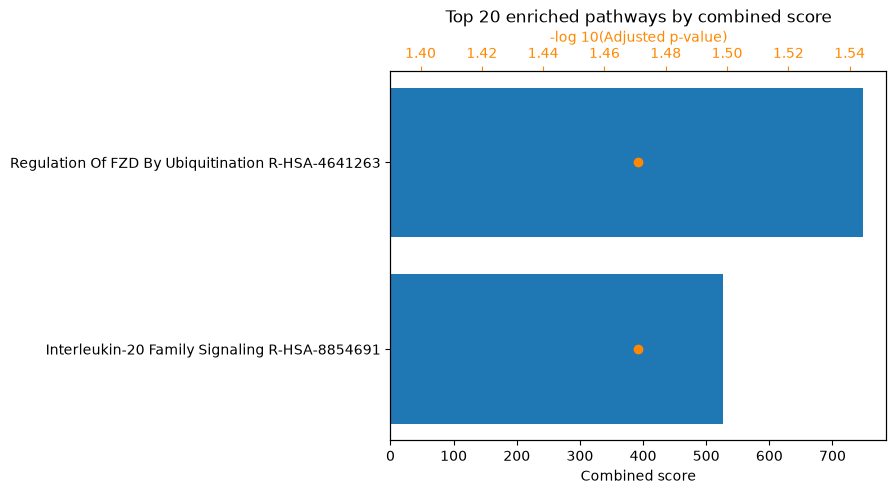

In [9]:
from IPython.display import display

background = pd.read_csv(DATA / "background_genes.csv", header=None)[0].astype(str).tolist()

hmi_results, hmi_figure = run_enrichment_analysis(monte_carlo, background, "HMI")
print(f"HMI enrichment: {len(hmi_results)} significant terms")
display(hmi_results.head())
hmi_figure

TieDIE enrichment: 795 significant terms


,rank,path_name,p_val,z_score,combined_score,overlapping_genes,adj_p_val,database
0,1,Signal Transduction R-HSA-162582,1.768027e-76,3.559268,620.830968,"[CYFIP2, TFRC, MAML1, ITSN1, STMN2, WDR83, RBP...",2.906637e-73,Reactome_2022
1,2,Generic Transcription Pathway R-HSA-212436,2.064974e-59,4.01188,542.114892,"[RB1, CCNK, SMARCB1, MAML1, EHMT1, CCNC, RBPJ,...",1.697408e-56,Reactome_2022
2,3,Disease R-HSA-1643685,2.434846e-57,3.297338,429.832588,"[RB1, CYFIP2, APP, CCNK, MAML1, ZDHHC5, KEAP1,...",1.334295e-54,Reactome_2022
3,4,Immune System R-HSA-168256,1.780780e-54,3.156436,390.648607,"[CYFIP2, IFITM3, APP, CNTFR, IL1RN, IFITM1, LR...",7.319005e-52,Reactome_2022
4,5,Cytokine Signaling In Immune System R-HSA-1280215,1.463913e-52,5.05129,602.888186,"[IFITM3, CNTFR, APP, IFITM1, IL1RN, IFI35, IFI...",4.813346e-50,Reactome_2022


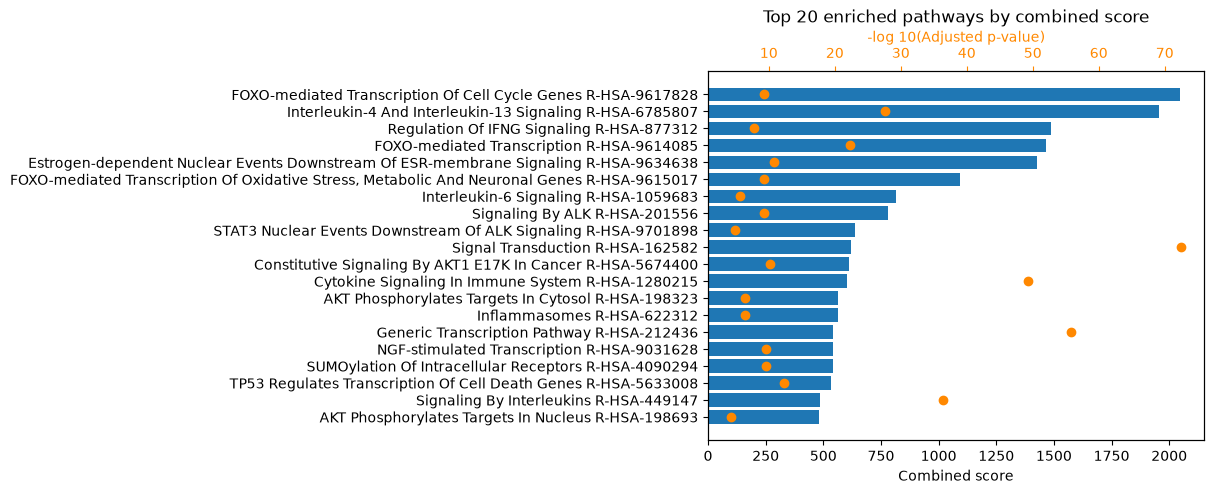

In [10]:
tiedie_results, tiedie_figure = run_enrichment_analysis(network, background, "TieDIE")
print(f"TieDIE enrichment: {len(tiedie_results)} significant terms")
display(tiedie_results.head())
tiedie_figure

## Where to go next

That is a complete, default MicrobioLink run: host targets predicted, filtered for
confidence, propagated into the signalling network, and read out as enriched
pathways &mdash; all in the forward direction.

- Add the reverse direction and every module with the
  [comprehensive notebook](t1_api_full.md).
- Run the same steps from the terminal with the
  [default command-line tutorial](t4_cli_basic.md).
- See [Pipeline Concepts](../concepts.md) and the
  [API Reference](../api/index.md) for the details.